# Lecture 0 - The Iris Data Set: Introduction to Python, Jupyter, and Data Science
## 9/3/2025 - Wednesday Leture 0

## Cool Notes

- Markdown (.md) and Markup (LaTeX, .tex) usage in notebooks
- Can combine both inline
- '\$\$' centers everything within the opening and closing (pretty cool)

## ML Basics: The Iris Data Set

In [2]:
# Creating a k-nearest neighbors based on the Iris Data Set
import pandas as pd
import scipy as sc
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import math
import mglearn  # Helper utility functions (covered in textbook)

In [ ]:
# Pull in the iris dataset
features_names = ['sepal length(cm)', 'sepal width(cm)', 'petal length(cm)', 'petal width(cm)', 'species']

# Importing from site bc im lazy and dont want to download csv
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv', names=features_names, header=None)

# Note: Typically, repo architecture would have a /data/ folder where datasets are stored

In [5]:
print(df.columns)  # Print the column names
df  # Show the data frame

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [7]:
# Looking at pretty print
import pprint as pp 
pp.pprint(df) 

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


In [ ]:
# Looking at more of the df
print(df.shape)  # (rows, columns)
print(df.head(2))  # First 5 rows
print(df.sample(5))  # Random sample of 5 rows
print(df.describe())  # Summary statistics
print(df['species'].value_counts())  # Count of each species
print(df.info())  # Information about the dataframe, such as memory usage

(150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
     sepal_length  sepal_width  petal_length  petal_width     species
56            6.3          3.3           4.7          1.6  versicolor
80            5.5          2.4           3.8          1.1  versicolor
143           6.8          3.2           5.9          2.3   virginica
134           6.1          2.6           5.6          1.4   virginica
10            5.4          3.7           1.5          0.2      setosa
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000

In [ ]:
print(df.dtypes)  # Get the datatypes from each field in the dataframe

In [11]:
species_names = df['species'].unique()  # Get the unique species names

# Iterate over the dataframe, calcilating new target numerical values for each:
for i in range(len(species_names)):
    df.loc[df['species'] == species_names[i], 'target'] = i
    
# df.loc  - Locate rows where the species column matches the current species name
# df['target'] = i  - Assign the corresponding numerical value to the new 'target' column
# This creates a new column 'target' in the dataframe with numerical values for each species
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species,target
81,5.5,2.4,3.7,1.0,versicolor,1.0
46,5.1,3.8,1.6,0.2,setosa,0.0
100,6.3,3.3,6.0,2.5,virginica,2.0
61,5.9,3.0,4.2,1.5,versicolor,1.0
122,7.7,2.8,6.7,2.0,virginica,2.0


In [13]:
# Recasting a column to a different datatype
df = df.astype({'target': 'int32'})  # We can choose the datatype for each column

df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species,target
123,6.3,2.7,4.9,1.8,virginica,2
88,5.6,3.0,4.1,1.3,versicolor,1
21,5.1,3.7,1.5,0.4,setosa,0
69,5.6,2.5,3.9,1.1,versicolor,1
22,4.6,3.6,1.0,0.2,setosa,0


In [14]:
# Get descriptive statistics from Panda dataframe
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [20]:
# Splitting the dataset in two ways - Vertical Split adn Horizontal Split

# Create a target only dataframe array:
target_df = df['target']  # Target only dataframe

# Create a dataframe that only includes the first four features
features_df = df[ df.columns[0:4] ]  # Only the first four features
features_df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width
141,6.9,3.1,5.1,2.3
39,5.1,3.4,1.5,0.2
58,6.6,2.9,4.6,1.3
60,5.0,2.0,3.5,1.0
122,7.7,2.8,6.7,2.0


In [23]:
# Row-Wise Split - Train/Test Split
from sklearn.model_selection import train_test_split

# Create a train/test split of the data (get training & testing sets)
X_train, X_test, y_train, y_test = train_test_split(features_df, target_df, random_state=0, train_size=0.75)
print(X_train.shape, y_train.shape)  # Training set shapes
print(X_test.shape, y_test.shape)    # Testing set shapes

(112, 4) (112,)
(38, 4) (38,)


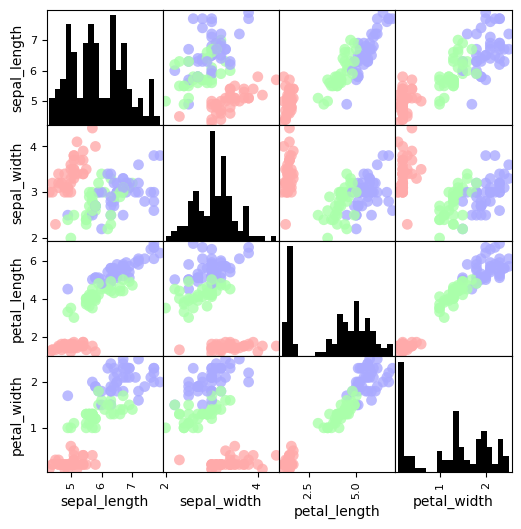

In [25]:
# Create a colormap

# Create new colormap of our choice:
import matplotlib.colors as mplcolors

custom_cm = mplcolors.ListedColormap(['#FF0000', '#00FF00', '#0000FF'])  # Red, Green, Blue
custom_cm2 = mplcolors.ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])  # Lighter colors

# Create a scatter matrix from the dataframe, scatter colors are given by species 'target' values in y_train
colormapScatterMatrix = pd.plotting.scatter_matrix(
                                                    X_train, 
                                                    c=y_train, 
                                                    figsize=(6, 6), 
                                                    marker='o',
                                                    hist_kwds={'bins': 20, 'color': 'black'}, 
                                                    s=60, 
                                                    alpha=.8, 
                                                    cmap=custom_cm2,
                                                )

